# Da Terra ao Código: Automatizando a Classificação de Grãos com Machine Learning

### FIAP — Atividade "Ir Além" | Fase 4 — Cap 3

---

## Contexto do problema

Em cooperativas agrícolas de pequeno porte, a classificação dos grãos de trigo é
feita **manualmente por especialistas**. Esse processo é:

- **Demorado** — depende da disponibilidade e do ritmo do avaliador humano;
- **Sujeito a erros** — fadiga, subjetividade e variação entre avaliadores;
- **Difícil de escalar** — o volume de grãos cresce mais rápido que a mão de obra especializada.

A proposta deste trabalho é **automatizar a classificação** de três variedades de
trigo — **Kama**, **Rosa** e **Canadian** — a partir de medições físicas dos grãos,
utilizando algoritmos de *Machine Learning*.

## Metodologia: CRISP-DM

O projeto segue as seis fases do **CRISP-DM** (*Cross Industry Standard Process for
Data Mining*):

| Fase | O que fazemos aqui |
|------|--------------------|
| 1. **Business Understanding** | Entender o problema de classificação na cooperativa |
| 2. **Data Understanding** | Explorar o *Seeds Dataset*, estatísticas e visualizações |
| 3. **Data Preparation** | Tratar dados, dividir treino/teste e padronizar escalas |
| 4. **Modeling** | Treinar e comparar 5 algoritmos de classificação |
| 5. **Evaluation** | Otimizar hiperparâmetros e interpretar os resultados |
| 6. **Deployment** | Recomendações de uso na cooperativa (discussão final) |


## Fase 1 — Business Understanding (Entendimento do Negócio)

**Objetivo de negócio:** reduzir o tempo e o erro da classificação manual de grãos
de trigo em cooperativas, oferecendo um classificador automático confiável.

**Objetivo de mineração de dados (tradução técnica):** treinar um modelo de
**classificação supervisionada multiclasse** que, a partir de 7 medições físicas do
grão, prediga corretamente sua variedade (Kama, Rosa ou Canadian).

**Critério de sucesso:** acurácia elevada (meta de referência ≥ 90%) e bom equilíbrio
entre **precisão** e **recall** nas três variedades — nenhuma classe pode ser
sistematicamente confundida, pois isso geraria lotes mal classificados.

### O conjunto de dados — *Seeds Dataset* (UCI)

210 amostras, 70 de cada variedade. Sete atributos contínuos medidos por imagem
de raio-X suave dos grãos:

| # | Atributo | Descrição |
|---|----------|-----------|
| 1 | `area` | Área do grão (A) |
| 2 | `perimetro` | Comprimento do contorno do grão (P) |
| 3 | `compacidade` | Compacidade, C = 4·π·A / P² |
| 4 | `comprimento_nucleo` | Comprimento do eixo principal da elipse equivalente |
| 5 | `largura_nucleo` | Comprimento do eixo secundário da elipse |
| 6 | `coef_assimetria` | Coeficiente de assimetria do grão |
| 7 | `comprimento_sulco` | Comprimento do sulco central do grão |
| — | `variedade` | **Alvo:** 1 = Kama, 2 = Rosa, 3 = Canadian |


## Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# Configuracoes visuais
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## Fase 2 — Data Understanding (Entendimento dos Dados)

### 2.1 Importação do conjunto de dados

O arquivo `seeds_dataset.txt` vem do UCI separado por **tabulações**, mas com
espaçamento irregular (algumas linhas têm tabulações duplicadas). Usamos o separador
de *whitespace* (`\s+`) para ler de forma robusta e nomeamos as colunas.

In [2]:
colunas = ["area", "perimetro", "compacidade", "comprimento_nucleo",
           "largura_nucleo", "coef_assimetria", "comprimento_sulco", "variedade"]

df = pd.read_csv("seeds/seeds_dataset.txt", sep=r"\s+", header=None, names=colunas)

# Mapeia o codigo numerico para o nome da variedade (apenas para leitura/graficos)
nomes_variedade = {1: "Kama", 2: "Rosa", 3: "Canadian"}
df["variedade_nome"] = df["variedade"].map(nomes_variedade)

print(f"Formato do dataset: {df.shape[0]} amostras x {df.shape[1]-1} colunas (+ rotulo legivel)")
df.head(10)

Formato do dataset: 210 amostras x 8 colunas (+ rotulo legivel)


,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,variedade,variedade_nome
0,15.2600,14.8400,0.8710,5.7630,3.3120,2.2210,5.2200,1,Kama
1,14.8800,14.5700,0.8811,5.5540,3.3330,1.0180,4.9560,1,Kama
2,14.2900,14.0900,0.9050,5.2910,3.3370,2.6990,4.8250,1,Kama
3,13.8400,13.9400,0.8955,5.3240,3.3790,2.2590,4.8050,1,Kama
4,16.1400,14.9900,0.9034,5.6580,3.5620,1.3550,5.1750,1,Kama
5,14.3800,14.2100,0.8951,5.3860,3.3120,2.4620,4.9560,1,Kama
6,14.6900,14.4900,0.8799,5.5630,3.2590,3.5860,5.2190,1,Kama
7,14.1100,14.1000,0.8911,5.4200,3.3020,2.7000,5.0000,1,Kama
8,16.6300,15.4600,0.8747,6.0530,3.4650,2.0400,5.8770,1,Kama
9,16.4400,15.2500,0.8880,5.8840,3.5050,1.9690,5.5330,1,Kama


### 2.2 Estrutura e tipos de dados

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                210 non-null    float64
 1   perimetro           210 non-null    float64
 2   compacidade         210 non-null    float64
 3   comprimento_nucleo  210 non-null    float64
 4   largura_nucleo      210 non-null    float64
 5   coef_assimetria     210 non-null    float64
 6   comprimento_sulco   210 non-null    float64
 7   variedade           210 non-null    int64  
 8   variedade_nome      210 non-null    str    
dtypes: float64(7), int64(1), str(1)
memory usage: 16.0 KB


### 2.3 Verificação de valores ausentes

A primeira checagem de qualidade do CRISP-DM: confirmar se há células vazias que
precisariam de tratamento (imputação ou remoção).

In [4]:
ausentes = df.isnull().sum()
print("Valores ausentes por coluna:")
print(ausentes)
print(f"\nTotal de valores ausentes no dataset: {ausentes.sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Valores ausentes por coluna:
area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
variedade             0
variedade_nome        0
dtype: int64

Total de valores ausentes no dataset: 0
Linhas duplicadas: 0


> **Observação:** o *Seeds Dataset* não possui valores ausentes nem duplicatas —
> é um conjunto limpo e curado. Ainda assim, mantemos a verificação explícita porque
> ela é uma etapa obrigatória do CRISP-DM e o código já fica pronto para dados reais
> da cooperativa, que dificilmente virão tão limpos.

### 2.4 Estatísticas descritivas (média, mediana, desvio padrão)

Calculamos as medidas de tendência central e dispersão para cada característica.

In [5]:
features = colunas[:-1]  # tudo menos 'variedade'

estatisticas = pd.DataFrame({
    "media":        df[features].mean(),
    "mediana":      df[features].median(),
    "desvio_padrao": df[features].std(),
    "minimo":       df[features].min(),
    "maximo":       df[features].max(),
    "amplitude":    df[features].max() - df[features].min(),
    "CV(%)":        (df[features].std() / df[features].mean() * 100),
})
estatisticas

,media,mediana,desvio_padrao,minimo,maximo,amplitude,CV(%)
area,14.8475,14.3550,2.9097,10.5900,21.1800,10.5900,19.5972
perimetro,14.5593,14.3200,1.3060,12.4100,17.2500,4.8400,8.9699
compacidade,0.8710,0.8735,0.0236,0.8081,0.9183,0.1102,2.7129
comprimento_nucleo,5.6285,5.5235,0.4431,4.8990,6.6750,1.7760,7.8717
largura_nucleo,3.2586,3.2370,0.3777,2.6300,4.0330,1.4030,11.5913
coef_assimetria,3.7002,3.5990,1.5036,0.7651,8.4560,7.6909,40.6345
comprimento_sulco,5.4081,5.2230,0.4915,4.5190,6.5500,2.0310,9.0879


**Leitura das estatísticas:**

- As características estão em **escalas muito diferentes** — `area` varia ~10 a ~21,
  enquanto `compacidade` fica entre ~0,81 e ~0,92. Isso já sinaliza que precisaremos
  **padronizar** os dados antes de algoritmos sensíveis a escala (KNN, SVM, Regressão Logística).
- O `coef_assimetria` tem o **maior coeficiente de variação (CV)**, ou seja, é a
  característica mais dispersa em termos relativos — potencialmente útil para separar classes.
- Média e mediana próximas na maioria das colunas sugerem distribuições razoavelmente
  simétricas, exceto onde houver assimetria (a inspecionar nos histogramas).

### 2.5 Balanceamento das classes

Em classificação, é essencial saber se as classes estão equilibradas — caso contrário,
a acurácia pode enganar.

variedade_nome
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


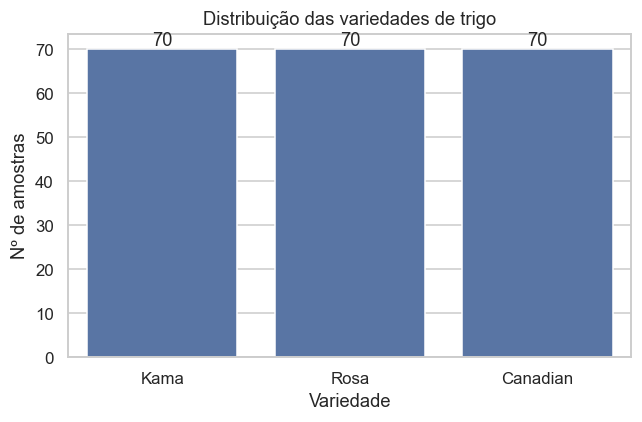

In [6]:
contagem = df["variedade_nome"].value_counts().reindex(["Kama", "Rosa", "Canadian"])
print(contagem)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="variedade_nome", order=["Kama", "Rosa", "Canadian"], ax=ax)
ax.set_title("Distribuição das variedades de trigo")
ax.set_xlabel("Variedade"); ax.set_ylabel("Nº de amostras")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()

> **Dataset perfeitamente balanceado:** 70 amostras por variedade (33,3% cada).
> Isso simplifica a avaliação — a acurácia é uma métrica confiável aqui — mas ainda
> reportaremos precisão, recall e F1 por classe para garantir.

### 2.6 Distribuição das características — Histogramas

Histogramas mostram a forma da distribuição de cada variável e ajudam a identificar
assimetrias e possíveis múltiplos modos (que costumam indicar separação entre classes).

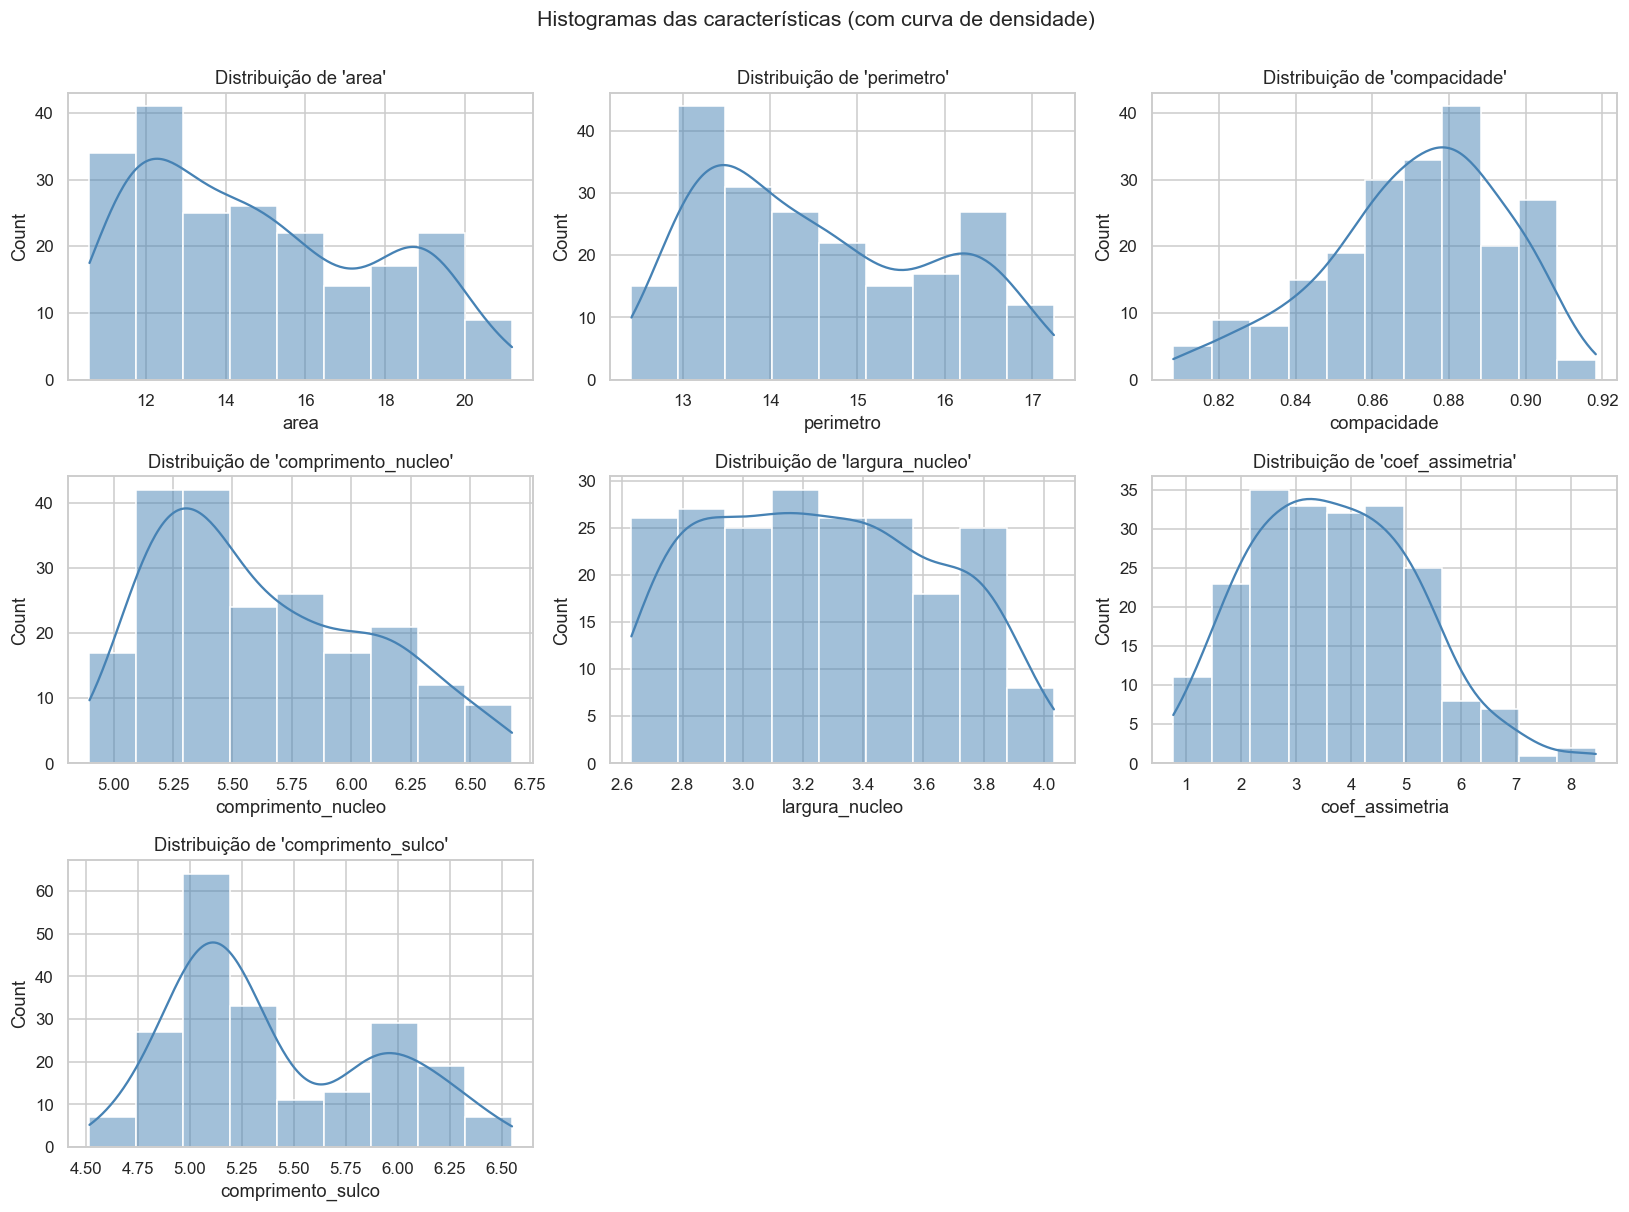

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribuição de '{col}'")
# remove eixos vazios sobrando
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Histogramas das características (com curva de densidade)", fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

**Interpretação dos histogramas:** várias características (`area`, `perimetro`,
`comprimento_nucleo`, `largura_nucleo`, `comprimento_sulco`) apresentam distribuição
**bimodal/multimodal** — um forte indício de que existem grupos naturais nos dados,
exatamente as variedades que queremos separar. O `coef_assimetria` é claramente
assimétrico à direita.

### 2.7 Histogramas segmentados por variedade

Sobrepondo a distribuição por classe, fica visível **quais características separam
bem as variedades**.

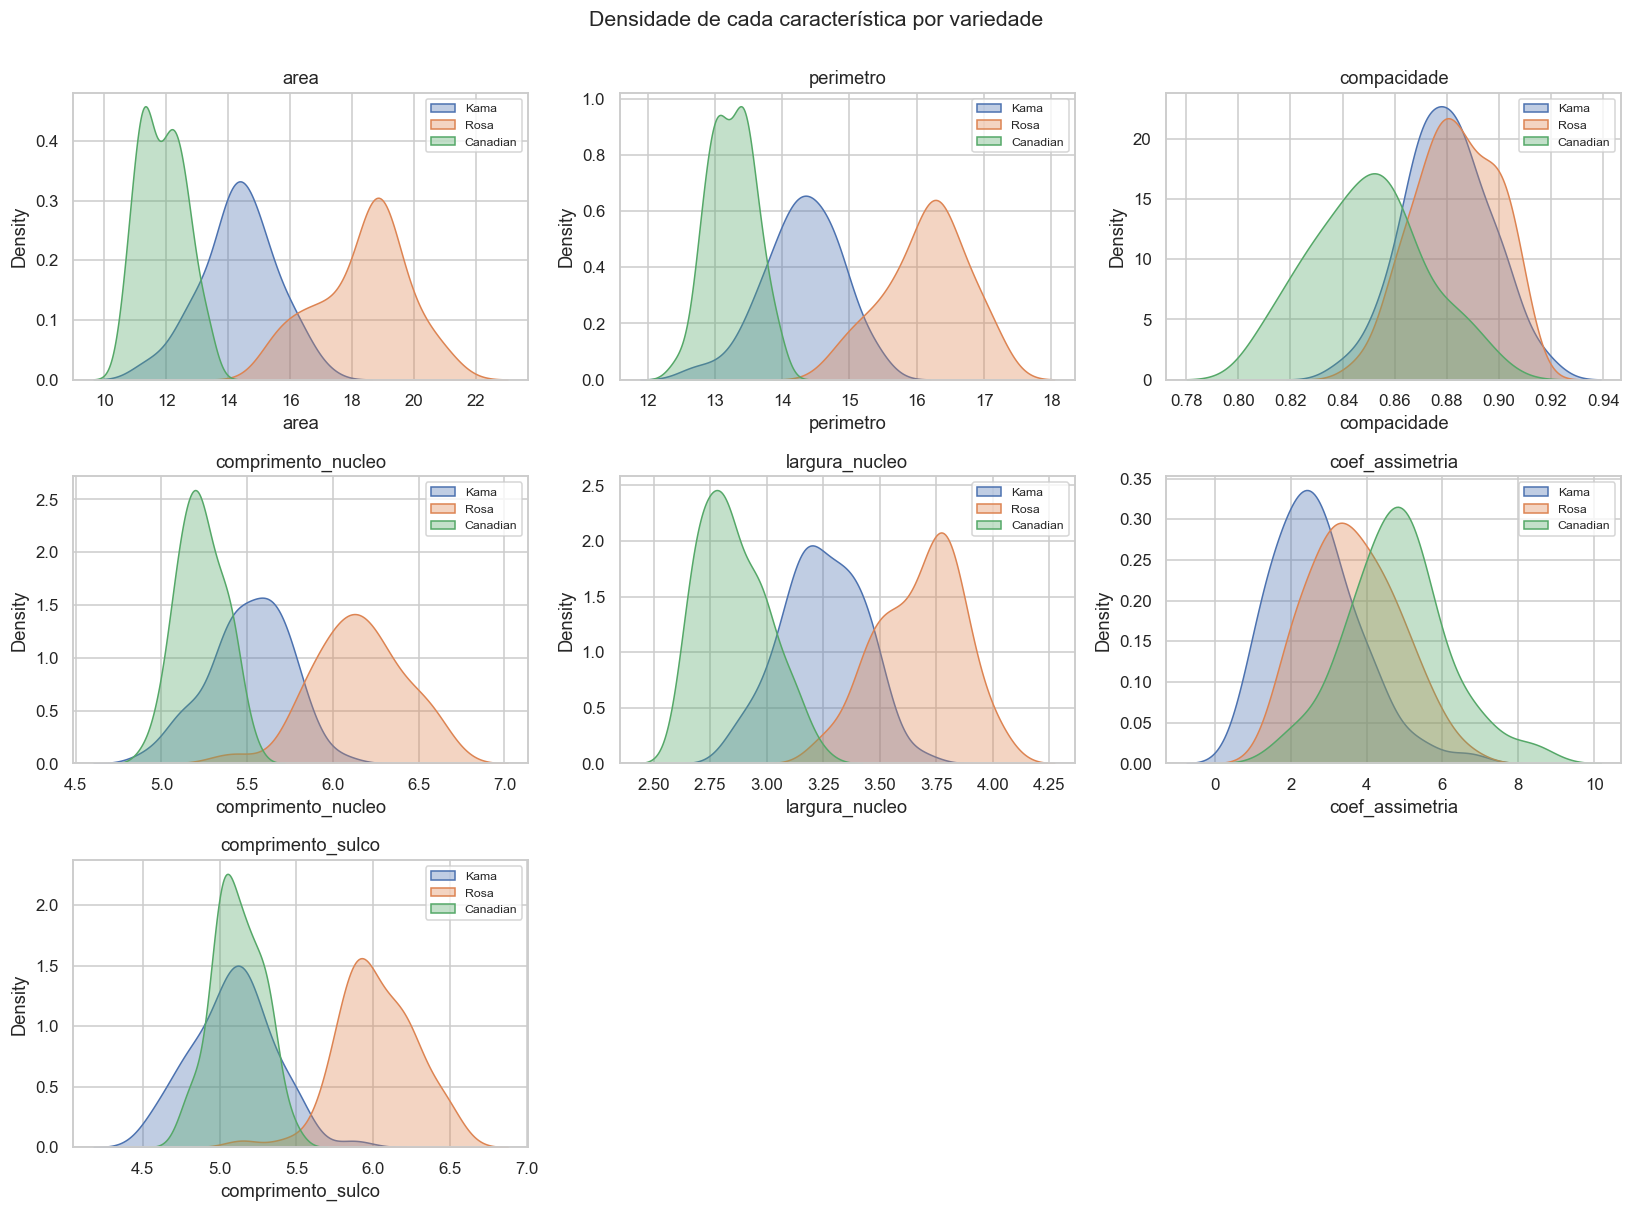

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for i, col in enumerate(features):
    for v in ["Kama", "Rosa", "Canadian"]:
        sns.kdeplot(df.loc[df["variedade_nome"] == v, col], ax=axes[i],
                    fill=True, alpha=0.35, label=v)
    axes[i].set_title(col); axes[i].legend(fontsize=8)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Densidade de cada característica por variedade", fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

**Insight:** `area`, `perimetro`, `comprimento_nucleo` e `comprimento_sulco`
separam muito bem a variedade **Rosa** (grãos maiores) das demais. A **Canadian**
tende a ter os menores valores. A **Kama** fica no meio — é a que mais se sobrepõe
às outras e, portanto, a que tende a gerar mais confusão nos modelos.

### 2.8 Boxplots — dispersão e *outliers*

Boxplots resumem mediana, quartis e valores atípicos. Padronizamos para comparar
todas as características num mesmo gráfico.

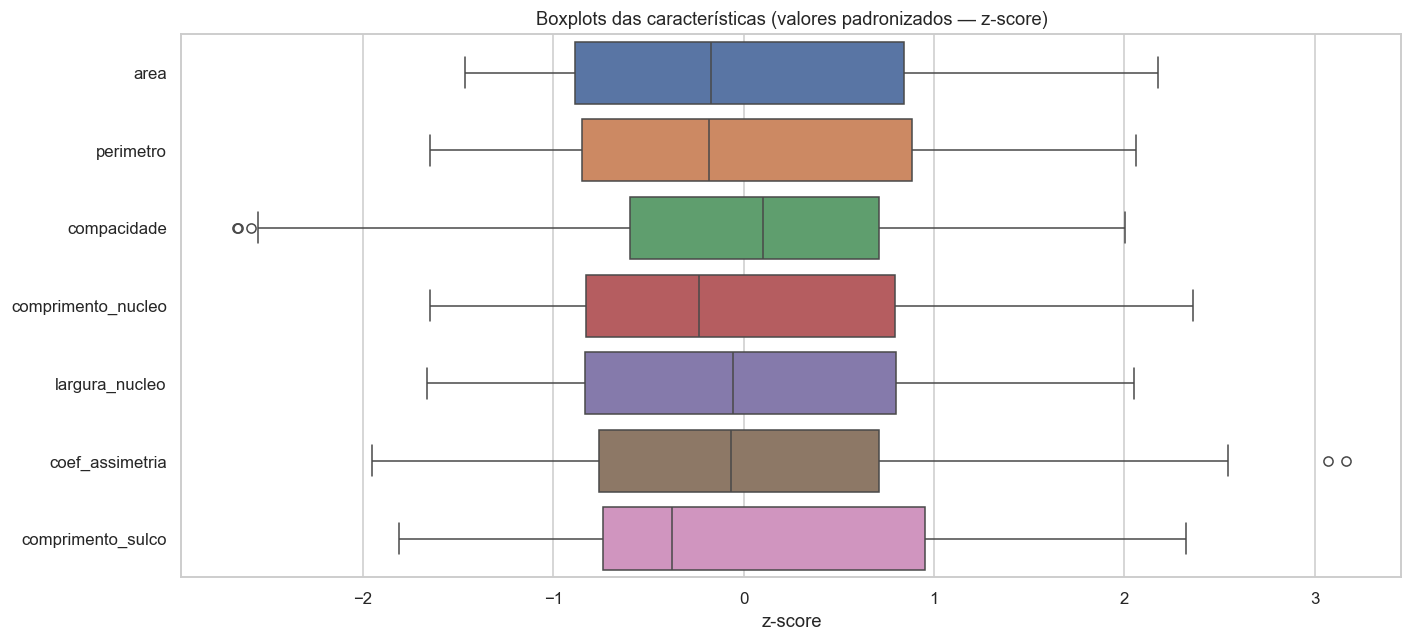

In [9]:
# Boxplot por caracteristica (escala padronizada apenas para visualizacao)
df_z = (df[features] - df[features].mean()) / df[features].std()

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_z, ax=ax, orient="h")
ax.set_title("Boxplots das características (valores padronizados — z-score)")
ax.set_xlabel("z-score")
plt.tight_layout(); plt.show()

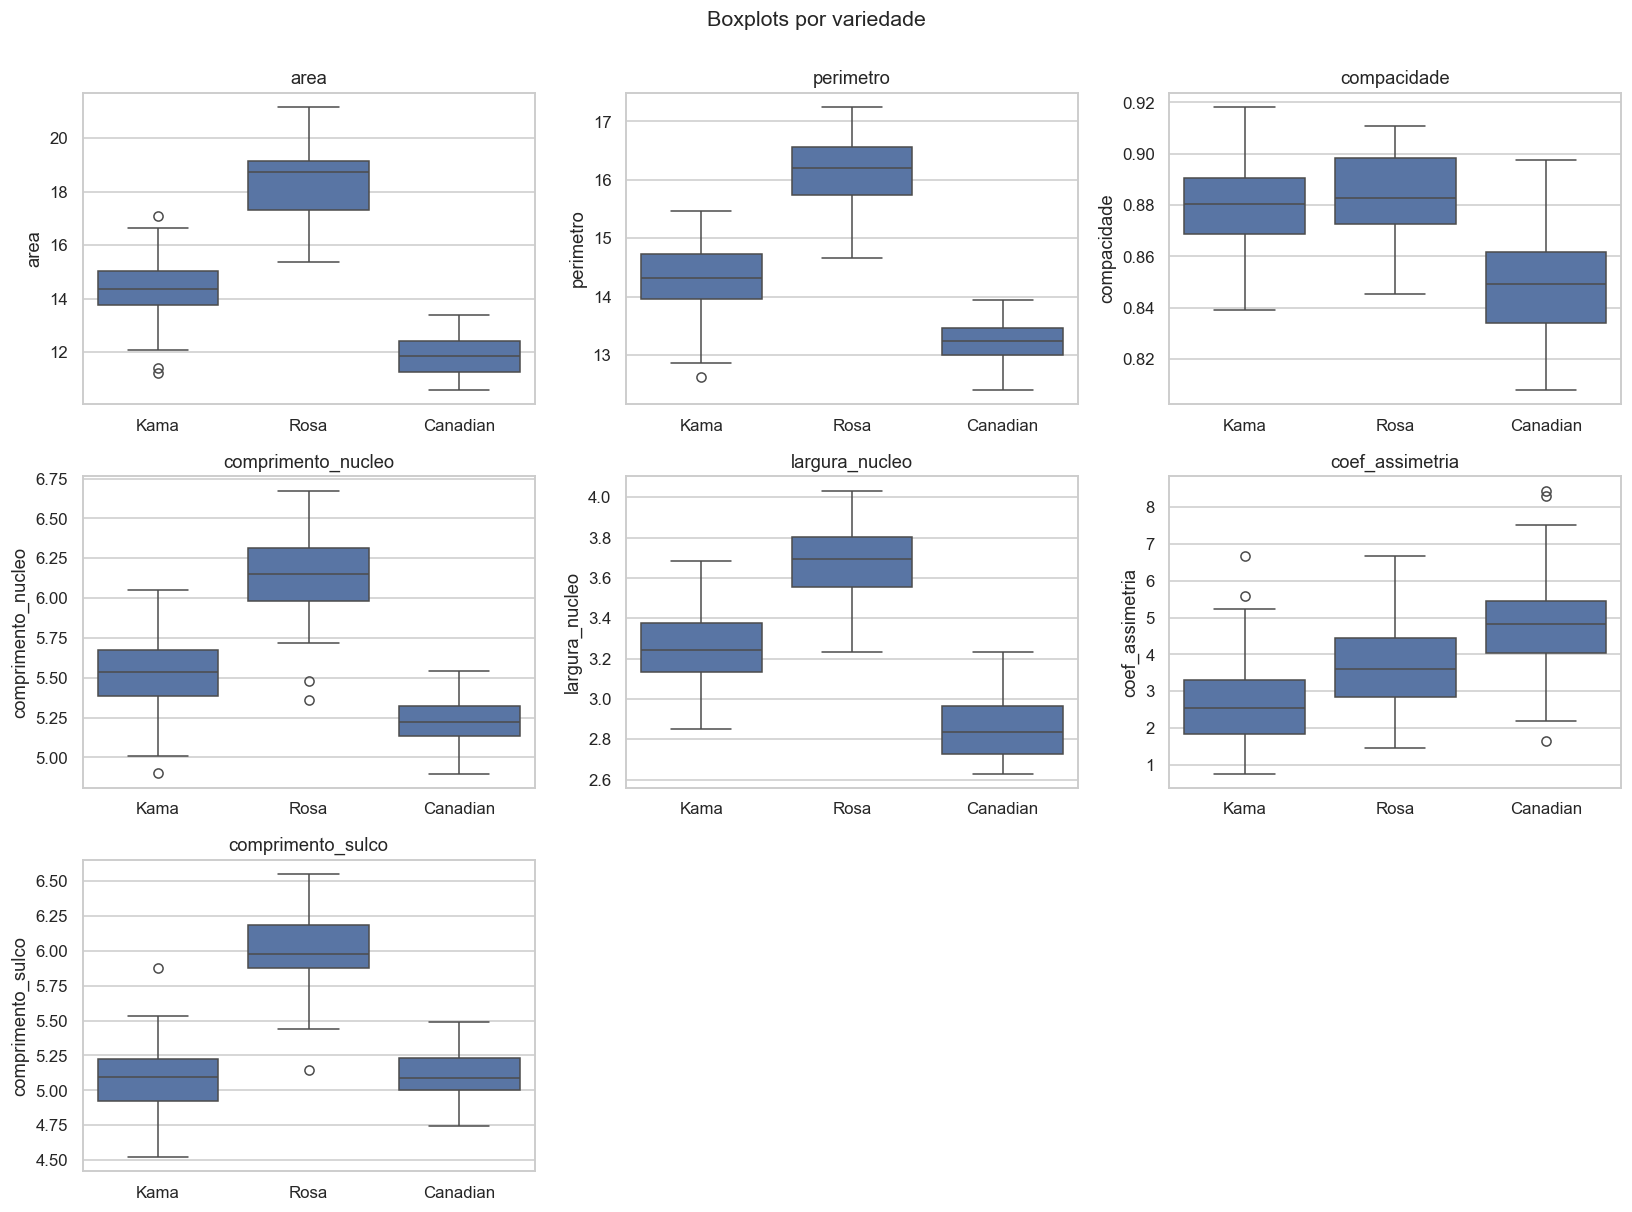

In [10]:
# Boxplot de cada caracteristica separado por variedade
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for i, col in enumerate(features):
    sns.boxplot(data=df, x="variedade_nome", y=col,
                order=["Kama", "Rosa", "Canadian"], ax=axes[i])
    axes[i].set_title(col); axes[i].set_xlabel("")
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Boxplots por variedade", fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

**Interpretação dos boxplots:** confirmam o que vimos nas densidades — `area`,
`perimetro` e dimensões do núcleo crescem de Canadian → Kama → Rosa. Há alguns poucos
*outliers* (sobretudo em `compacidade` e `coef_assimetria`), mas são **valores
fisicamente plausíveis** (grãos naturalmente atípicos), não erros de medição.
Por isso **não os removemos** — eles fazem parte da variabilidade real do trigo e
modelos robustos (como Random Forest) lidam bem com eles.

### 2.9 Relações entre características — Dispersão e Correlação

Gráficos de dispersão revelam relações entre pares de variáveis e quão bem elas
separam as classes.

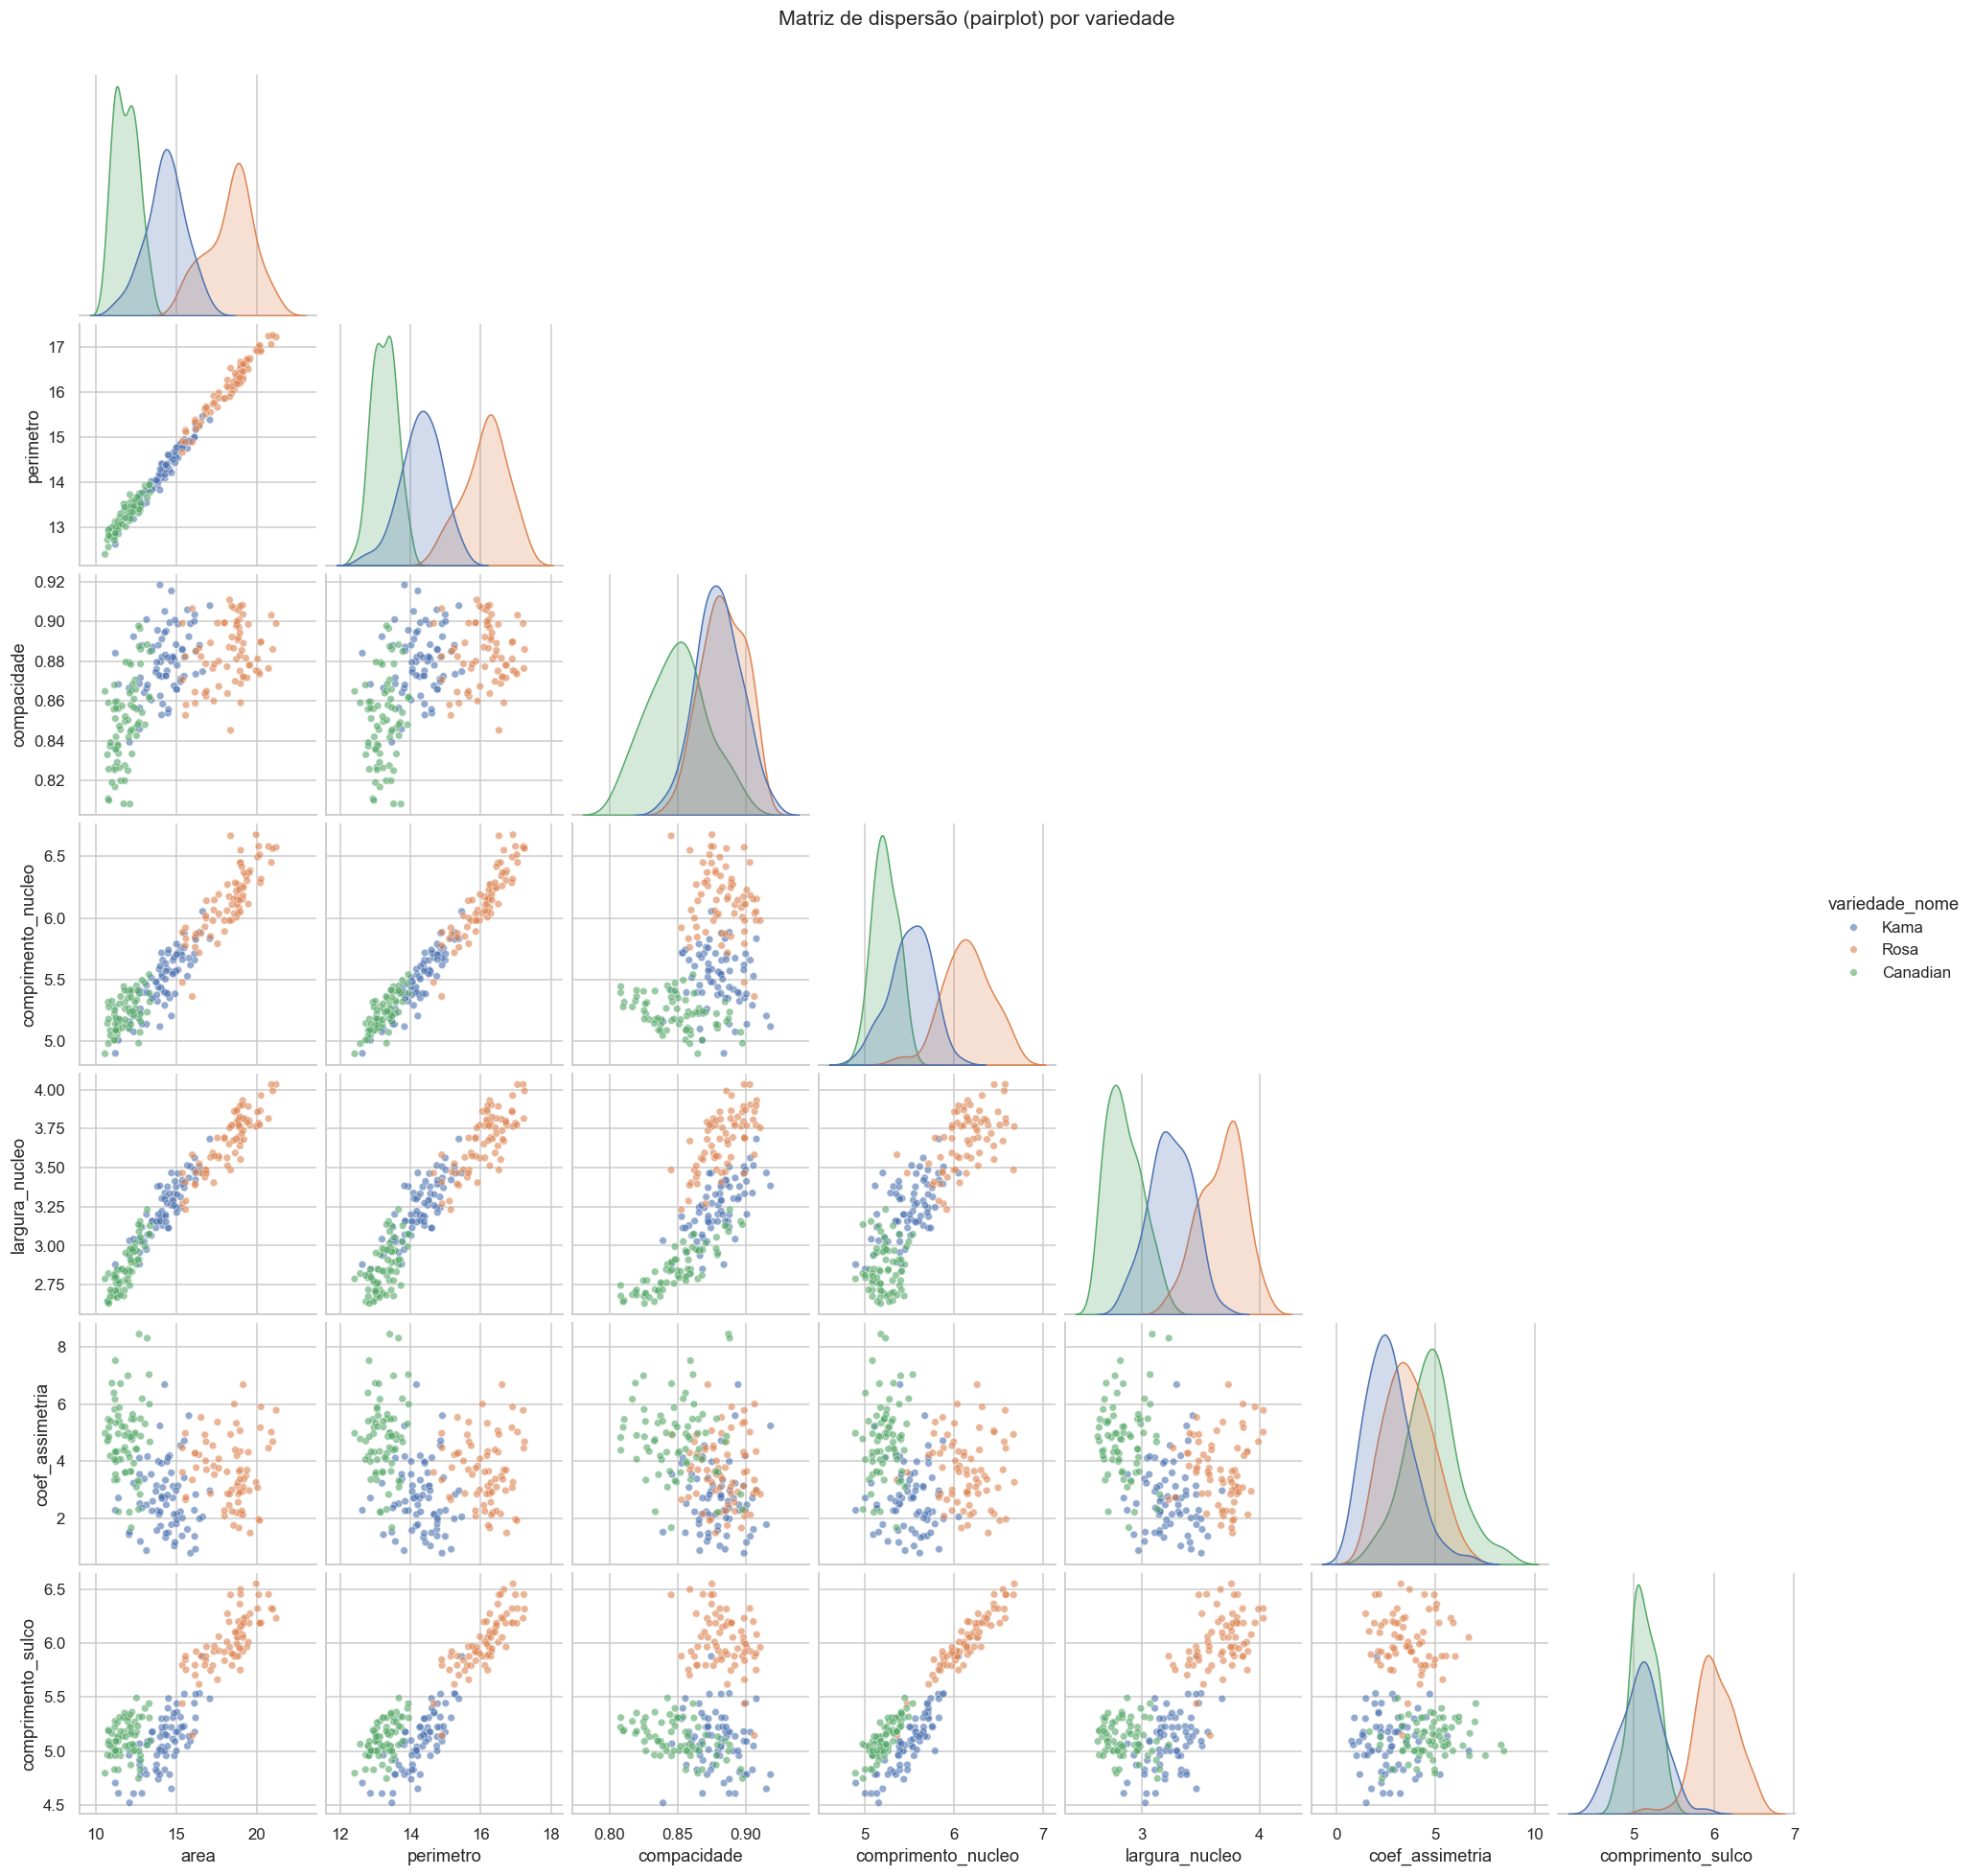

In [11]:
pair = sns.pairplot(df, vars=features, hue="variedade_nome",
                    hue_order=["Kama", "Rosa", "Canadian"],
                    corner=True, diag_kind="kde", plot_kws={"alpha": 0.6, "s": 25})
pair.fig.suptitle("Matriz de dispersão (pairplot) por variedade", y=1.02, fontsize=14)
plt.show()

### 2.10 Matriz de correlação

Identifica características redundantes (altamente correlacionadas), o que ajuda a
entender a estrutura dos dados.

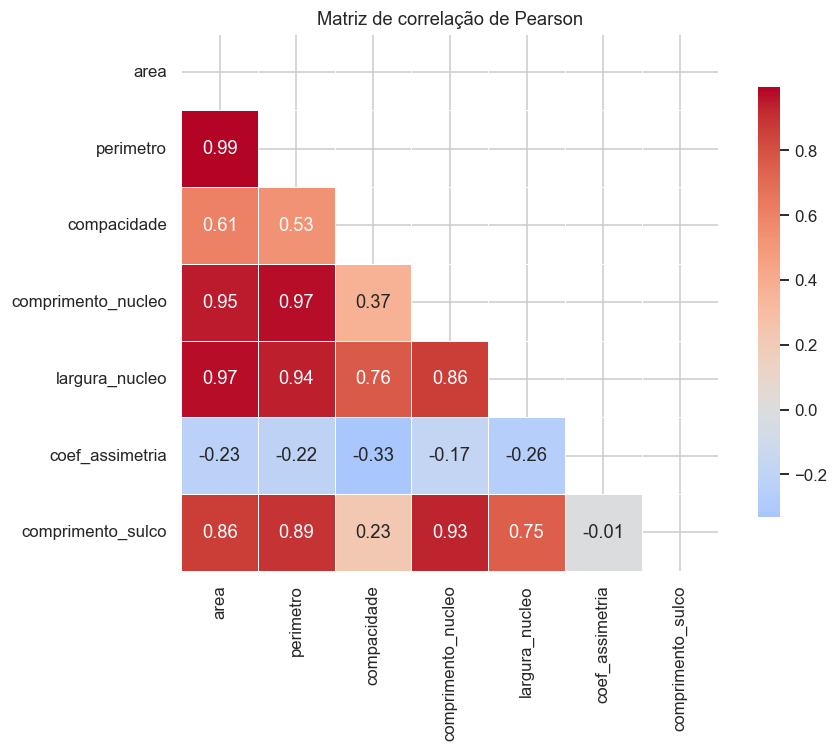

In [12]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=.5, ax=ax,
            cbar_kws={"shrink": .8})
ax.set_title("Matriz de correlação de Pearson")
plt.tight_layout(); plt.show()

**Insight de correlação:** existe **multicolinearidade forte** entre as medidas de
tamanho — `area`, `perimetro`, `comprimento_nucleo`, `largura_nucleo` e
`comprimento_sulco` têm correlações acima de 0,8. Faz sentido físico: grãos maiores
são maiores em todas as dimensões.

Consequências práticas:
- Modelos lineares (Regressão Logística) podem sofrer com colinearidade — a
  **padronização** e a regularização ajudam.
- Há **redundância de informação**: poucas características já carregam grande parte do
  sinal. Isso explica por que modelos simples já costumam acertar muito neste dataset.
- A `compacidade` e o `coef_assimetria` são as menos correlacionadas com as demais —
  trazem informação **complementar** e provavelmente são úteis para os modelos.

## Fase 3 — Data Preparation (Preparação dos Dados)

### 3.1 Separação de atributos (X) e alvo (y)

In [13]:
X = df[features].copy()
y = df["variedade"].copy()   # alvo numerico (1, 2, 3)

print("X (atributos):", X.shape)
print("y (alvo):     ", y.shape)
print("Classes:", sorted(y.unique()), "->", [nomes_variedade[c] for c in sorted(y.unique())])

X (atributos): (210, 7)
y (alvo):      (210,)
Classes: [np.int64(1), np.int64(2), np.int64(3)] -> ['Kama', 'Rosa', 'Canadian']


### 3.2 Divisão treino / teste (70% / 30%)

Usamos **`stratify=y`** para manter a proporção das três variedades igual em treino e
teste — fundamental num problema multiclasse.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print(f"Treino: {X_train.shape[0]} amostras (70%)")
print(f"Teste:  {X_test.shape[0]} amostras (30%)")
print("\nProporção das classes no treino:")
print(y_train.map(nomes_variedade).value_counts(normalize=True).round(3))
print("\nProporção das classes no teste:")
print(y_test.map(nomes_variedade).value_counts(normalize=True).round(3))

Treino: 147 amostras (70%)
Teste:  63 amostras (30%)

Proporção das classes no treino:
variedade
Kama       0.3330
Canadian   0.3330
Rosa       0.3330
Name: proportion, dtype: float64

Proporção das classes no teste:
variedade
Rosa       0.3330
Canadian   0.3330
Kama       0.3330
Name: proportion, dtype: float64


### 3.3 Padronização das características (escalonamento)

Como vimos na Fase 2, as características estão em escalas muito diferentes. Algoritmos
baseados em **distância** (KNN), em **margens geométricas** (SVM) ou em **gradiente**
(Regressão Logística) são sensíveis a isso — uma variável de maior magnitude dominaria
o cálculo.

Aplicamos **padronização (Z-score)** com `StandardScaler`. Ponto crítico de
metodologia: o *scaler* é **ajustado apenas no treino** (`fit_transform`) e somente
**aplicado** no teste (`transform`). Isso evita *data leakage* — o conjunto de teste
não pode influenciar a estatística usada na transformação.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # ajusta no treino
X_test_scaled  = scaler.transform(X_test)        # apenas aplica no teste

# Confirma: media ~0 e desvio ~1 no treino padronizado
print("Média das features no treino padronizado (≈0):")
print(np.round(X_train_scaled.mean(axis=0), 3))
print("\nDesvio-padrão no treino padronizado (≈1):")
print(np.round(X_train_scaled.std(axis=0), 3))

Média das features no treino padronizado (≈0):
[ 0.  0. -0.  0. -0.  0. -0.]

Desvio-padrão no treino padronizado (≈1):
[1. 1. 1. 1. 1. 1. 1.]


> **Nota sobre Random Forest e Naive Bayes:** esses algoritmos **não exigem**
> padronização (árvores são invariantes a escala; o GaussianNB modela cada feature
> separadamente). Mas usar os dados padronizados não os prejudica, então mantemos um
> fluxo único para simplicidade e comparação justa. Nos *pipelines* da otimização,
> cada modelo recebe o pré-processamento adequado.

## Fase 4 — Modeling (Modelagem)

### 4.1 Escolha dos algoritmos

Conforme solicitado, treinamos e comparamos **cinco** algoritmos de classificação,
cobrindo famílias bem diferentes:

| Algoritmo | Família | Por que incluir |
|-----------|---------|-----------------|
| **K-Nearest Neighbors (KNN)** | Baseado em instância/distância | Simples, eficaz quando classes formam grupos no espaço |
| **Support Vector Machine (SVM)** | Margem máxima / kernel | Forte em fronteiras não-lineares com poucos dados |
| **Random Forest** | Ensemble de árvores | Robusto, lida com outliers e dá importância das features |
| **Naive Bayes (Gaussiano)** | Probabilístico | *Baseline* rápido; assume independência das features |
| **Regressão Logística** | Linear | Interpretável; bom *baseline* linear |

### 4.2 Treinamento e avaliação dos modelos (configuração padrão)

Treinamos cada modelo no conjunto de treino padronizado e avaliamos no conjunto de
teste com **acurácia, precisão, recall e F1-score** (média *macro*, que pesa as três
classes igualmente).

In [16]:
modelos = {
    "KNN":                 KNeighborsClassifier(),
    "SVM":                 SVC(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(random_state=RANDOM_STATE),
    "Naive Bayes":         GaussianNB(),
    "Regressão Logística": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
}

resultados = []
predicoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    predicoes[nome] = y_pred
    resultados.append({
        "Modelo":    nome,
        "Acurácia":  accuracy_score(y_test, y_pred),
        "Precisão":  precision_score(y_test, y_pred, average="macro"),
        "Recall":    recall_score(y_test, y_pred, average="macro"),
        "F1-score":  f1_score(y_test, y_pred, average="macro"),
    })

resultados_base = pd.DataFrame(resultados).set_index("Modelo").sort_values("Acurácia", ascending=False)
print("Desempenho no conjunto de teste (modelos com configuração padrão):\n")
resultados_base.style.format("{:.4f}").background_gradient(cmap="Greens")

Desempenho no conjunto de teste (modelos com configuração padrão):


,Acurácia,Precisão,Recall,F1-score
Modelo,,,,
Random Forest,0.9206,0.9239,0.9206,0.9192
KNN,0.8730,0.8721,0.8730,0.8713
SVM,0.8730,0.8721,0.8730,0.8713
Regressão Logística,0.8571,0.8571,0.8571,0.8543
Naive Bayes,0.8254,0.8339,0.8254,0.8251


In [17]:
# Versao em texto (garante exibicao mesmo sem render de Styler)
print(resultados_base.round(4).to_string())

                     Acurácia  Precisão  Recall  F1-score
Modelo                                                   
Random Forest          0.9206    0.9239  0.9206    0.9192
KNN                    0.8730    0.8721  0.8730    0.8713
SVM                    0.8730    0.8721  0.8730    0.8713
Regressão Logística    0.8571    0.8571  0.8571    0.8543
Naive Bayes            0.8254    0.8339  0.8254    0.8251


### 4.3 Comparação visual dos modelos (base)

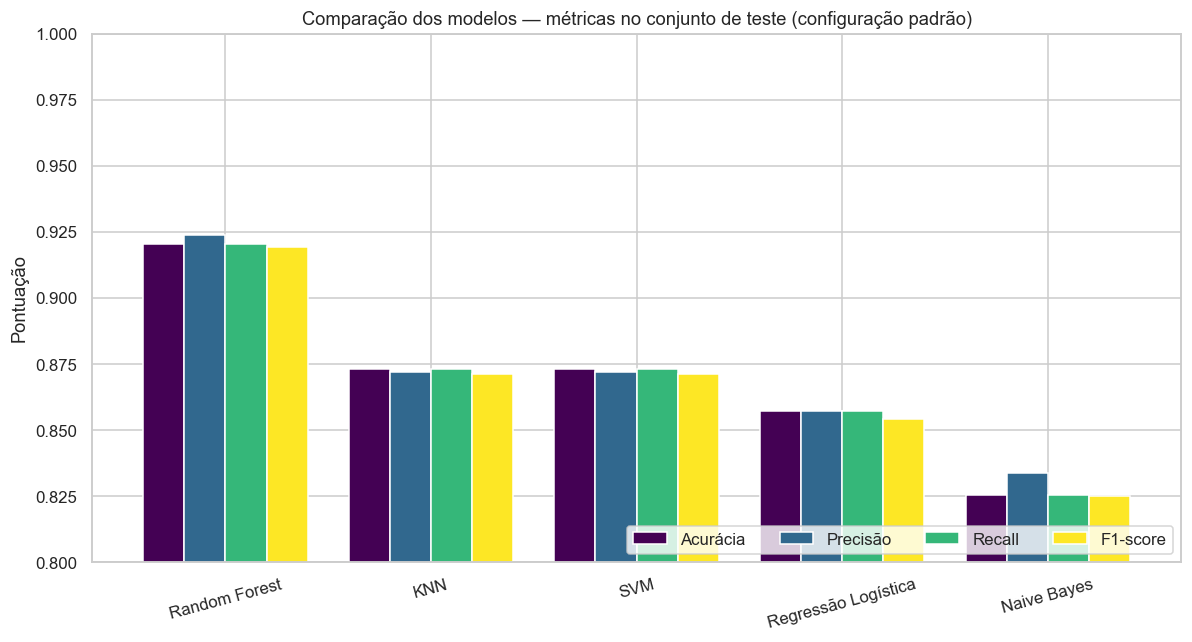

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
resultados_base.plot(kind="bar", ax=ax, width=0.8, colormap="viridis")
ax.set_title("Comparação dos modelos — métricas no conjunto de teste (configuração padrão)")
ax.set_ylabel("Pontuação"); ax.set_xlabel("")
ax.set_ylim(0.80, 1.0)
ax.legend(loc="lower right", ncol=4)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

### 4.4 Relatórios de classificação e matrizes de confusão (base)

A matriz de confusão mostra **onde** cada modelo erra — qual variedade é confundida
com qual. No nosso contexto, isso é mais informativo que a acurácia isolada.

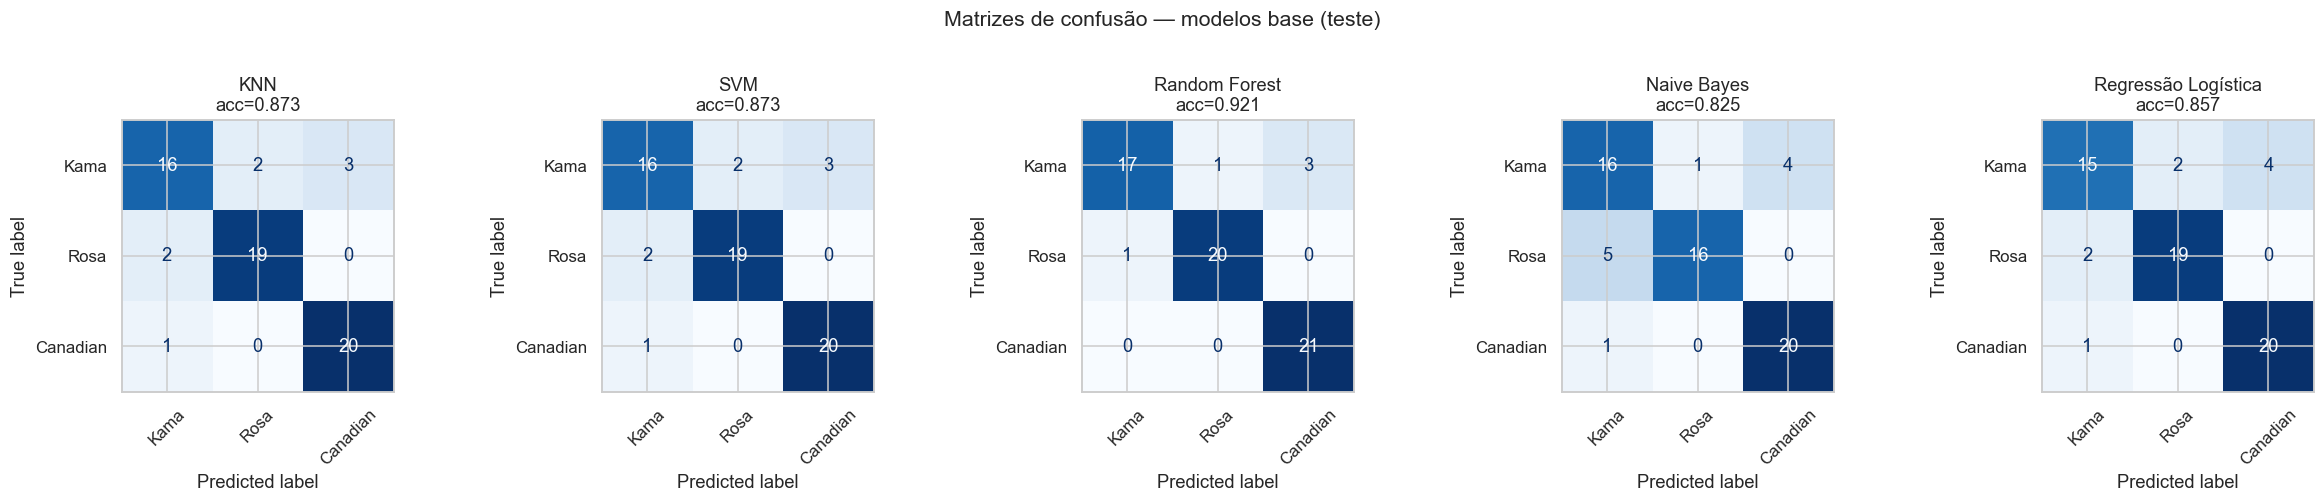

In [19]:
labels = [1, 2, 3]
labels_nome = ["Kama", "Rosa", "Canadian"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (nome, y_pred) in zip(axes, predicoes.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels_nome)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{nome}\nacc={accuracy_score(y_test, y_pred):.3f}")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Matrizes de confusão — modelos base (teste)", fontsize=14, y=1.05)
plt.tight_layout(); plt.show()

In [20]:
# Relatorio detalhado do melhor modelo base
melhor_base = resultados_base.index[0]
print(f"Relatório de classificação detalhado — melhor modelo base: {melhor_base}\n")
print(classification_report(y_test, predicoes[melhor_base],
                            target_names=labels_nome, digits=4))

Relatório de classificação detalhado — melhor modelo base: Random Forest

              precision    recall  f1-score   support

        Kama     0.9444    0.8095    0.8718        21
        Rosa     0.9524    0.9524    0.9524        21
    Canadian     0.8750    1.0000    0.9333        21

    accuracy                         0.9206        63
   macro avg     0.9239    0.9206    0.9192        63
weighted avg     0.9239    0.9206    0.9192        63



## Fase 5 — Otimização dos Modelos (Hyperparameter Tuning)

### 5.1 Estratégia

Mesmo com bons resultados de base, aplicamos **Grid Search com validação cruzada
estratificada (5 folds)** para buscar os melhores hiperparâmetros de cada modelo.

Pontos de metodologia:
- Usamos **`Pipeline`** unindo `StandardScaler` + modelo, de modo que a padronização é
  reajustada **dentro de cada fold** da validação cruzada — evitando *data leakage* na busca.
- A métrica de otimização é o **F1-score macro**, que equilibra as três variedades.
- O Grid Search vê **apenas o conjunto de treino**; o teste permanece intocado até a
  avaliação final.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Espaco de busca por modelo (dentro de um Pipeline com StandardScaler)
grids = {
    "KNN": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "param_grid": {
            "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],  # 1=Manhattan, 2=Euclidiana
        },
    },
    "SVM": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", SVC(random_state=RANDOM_STATE))]),
        "param_grid": {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.01, 0.1, 1],
            "clf__kernel": ["rbf", "linear"],
        },
    },
    "Random Forest": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
        "param_grid": {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [None, 4, 6, 8],
            "clf__min_samples_split": [2, 5],
            "clf__max_features": ["sqrt", "log2"],
        },
    },
    "Naive Bayes": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
        "param_grid": {
            "clf__var_smoothing": np.logspace(-11, -2, 10),
        },
    },
    "Regressão Logística": {
        "estimator": Pipeline([("scaler", StandardScaler()),
                               ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10, 100],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs", "newton-cg"],
        },
    },
}
print("Espaços de busca definidos para", len(grids), "modelos.")

Espaços de busca definidos para 5 modelos.


In [22]:
melhores_modelos = {}
linhas_otim = []

for nome, cfg in grids.items():
    gs = GridSearchCV(cfg["estimator"], cfg["param_grid"],
                      scoring="f1_macro", cv=cv, n_jobs=1)
    gs.fit(X_train, y_train)   # Pipeline cuida do scaling internamente -> usamos X_train cru
    melhores_modelos[nome] = gs.best_estimator_

    y_pred = gs.predict(X_test)
    linhas_otim.append({
        "Modelo":   nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, average="macro"),
        "Recall":   recall_score(y_test, y_pred, average="macro"),
        "F1-score": f1_score(y_test, y_pred, average="macro"),
        "F1 CV (treino)": gs.best_score_,
    })
    print(f"[{nome}] melhores params: {gs.best_params_}")
    print(f"    F1 macro (CV treino) = {gs.best_score_:.4f}\n")

resultados_otim = pd.DataFrame(linhas_otim).set_index("Modelo").sort_values("Acurácia", ascending=False)

[KNN] melhores params: {'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'uniform'}
    F1 macro (CV treino) = 0.9461



[SVM] melhores params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
    F1 macro (CV treino) = 0.9593



[Random Forest] melhores params: {'clf__max_depth': 4, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
    F1 macro (CV treino) = 0.9096



[Naive Bayes] melhores params: {'clf__var_smoothing': np.float64(1e-11)}
    F1 macro (CV treino) = 0.9234



C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\tamar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

[Regressão Logística] melhores params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
    F1 macro (CV treino) = 0.9514



In [23]:
print("Desempenho no conjunto de teste — modelos OTIMIZADOS:\n")
print(resultados_otim.round(4).to_string())
resultados_otim.style.format("{:.4f}").background_gradient(cmap="Greens")

Desempenho no conjunto de teste — modelos OTIMIZADOS:

                     Acurácia  Precisão  Recall  F1-score  F1 CV (treino)
Modelo                                                                   
Random Forest          0.9048    0.9112  0.9048    0.9025          0.9096
KNN                    0.8889    0.8880  0.8889    0.8881          0.9461
Regressão Logística    0.8889    0.8899  0.8889    0.8884          0.9514
SVM                    0.8571    0.8555  0.8571    0.8540          0.9593
Naive Bayes            0.8254    0.8339  0.8254    0.8251          0.9234


,Acurácia,Precisão,Recall,F1-score,F1 CV (treino)
Modelo,,,,,
Random Forest,0.9048,0.9112,0.9048,0.9025,0.9096
KNN,0.8889,0.8880,0.8889,0.8881,0.9461
Regressão Logística,0.8889,0.8899,0.8889,0.8884,0.9514
SVM,0.8571,0.8555,0.8571,0.8540,0.9593
Naive Bayes,0.8254,0.8339,0.8254,0.8251,0.9234


### 5.2 Antes x Depois da otimização

Comparamos o F1-score de cada modelo na configuração padrão e após o Grid Search,
para verificar se houve **melhoria significativa**.

                     F1 base  F1 otimizado    Δ F1
Modelo                                            
Random Forest         0.9192        0.9025 -0.0167
Regressão Logística   0.8543        0.8884  0.0341
KNN                   0.8713        0.8881  0.0168
SVM                   0.8713        0.8540 -0.0173
Naive Bayes           0.8251        0.8251  0.0000


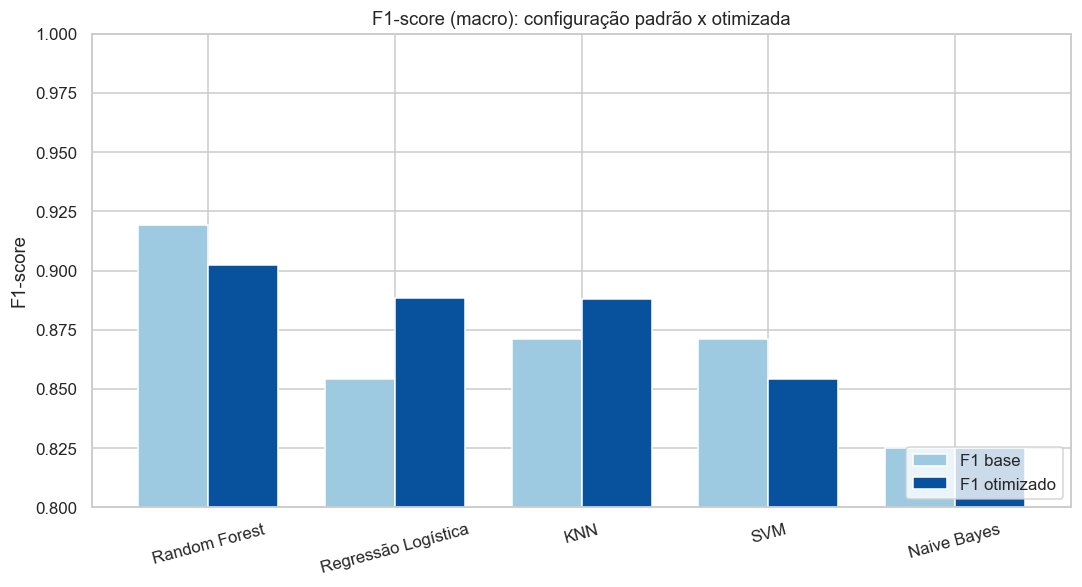

In [24]:
comparacao = pd.DataFrame({
    "F1 base":      resultados_base["F1-score"],
    "F1 otimizado": resultados_otim["F1-score"],
})
comparacao["Δ F1"] = comparacao["F1 otimizado"] - comparacao["F1 base"]
comparacao = comparacao.sort_values("F1 otimizado", ascending=False)
print(comparacao.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5.5))
comparacao[["F1 base", "F1 otimizado"]].plot(kind="bar", ax=ax, width=0.75,
                                             color=["#9ecae1", "#08519c"])
ax.set_title("F1-score (macro): configuração padrão x otimizada")
ax.set_ylabel("F1-score"); ax.set_xlabel("")
ax.set_ylim(0.80, 1.0); ax.tick_params(axis="x", rotation=15)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 5.3 Matrizes de confusão dos modelos otimizados

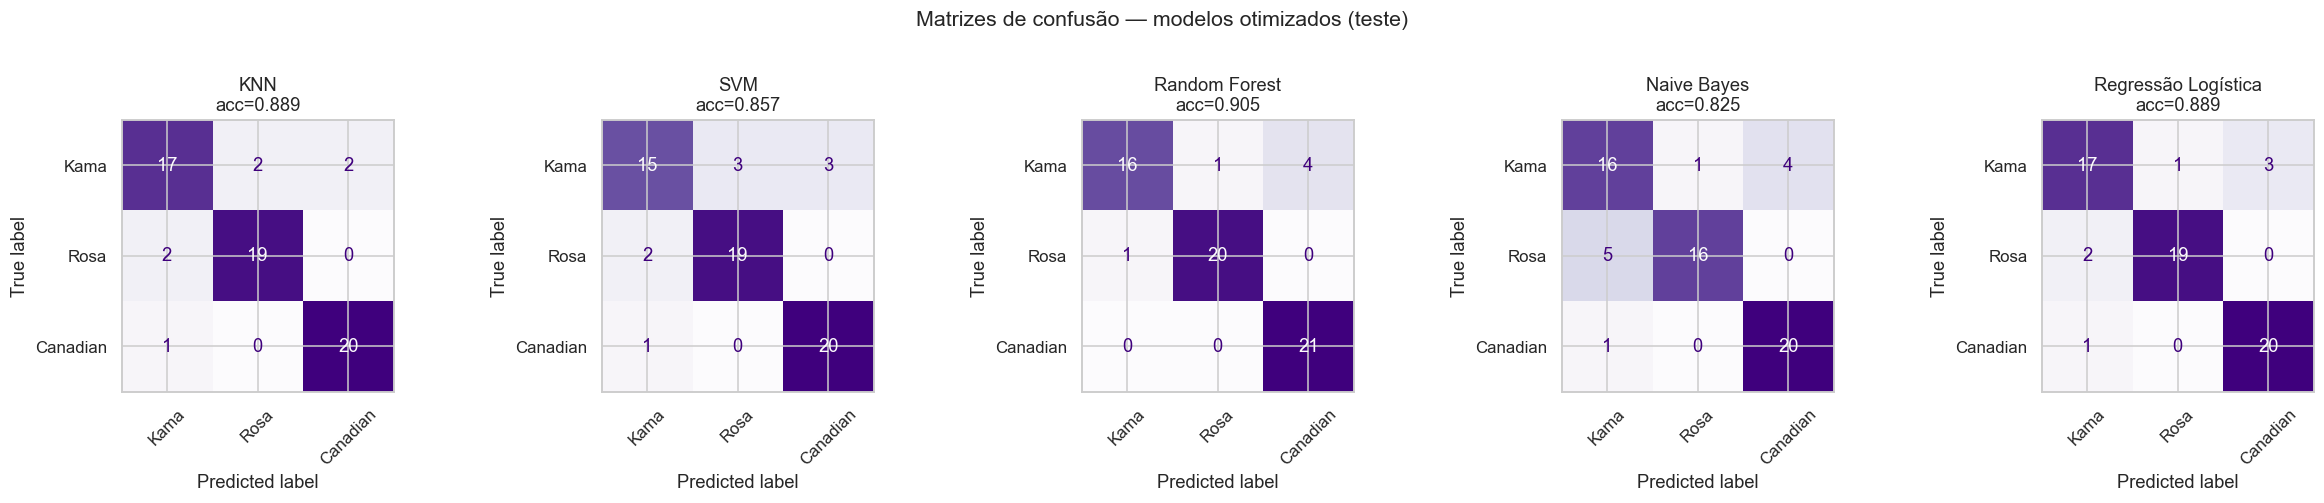

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (nome, modelo) in zip(axes, melhores_modelos.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels_nome).plot(ax=ax, cmap="Purples", colorbar=False)
    ax.set_title(f"{nome}\nacc={accuracy_score(y_test, y_pred):.3f}")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Matrizes de confusão — modelos otimizados (teste)", fontsize=14, y=1.05)
plt.tight_layout(); plt.show()

### 5.4 Seleção e análise do melhor modelo

MELHOR MODELO: Random Forest
              precision    recall  f1-score   support

        Kama     0.9412    0.7619    0.8421        21
        Rosa     0.9524    0.9524    0.9524        21
    Canadian     0.8400    1.0000    0.9130        21

    accuracy                         0.9048        63
   macro avg     0.9112    0.9048    0.9025        63
weighted avg     0.9112    0.9048    0.9025        63



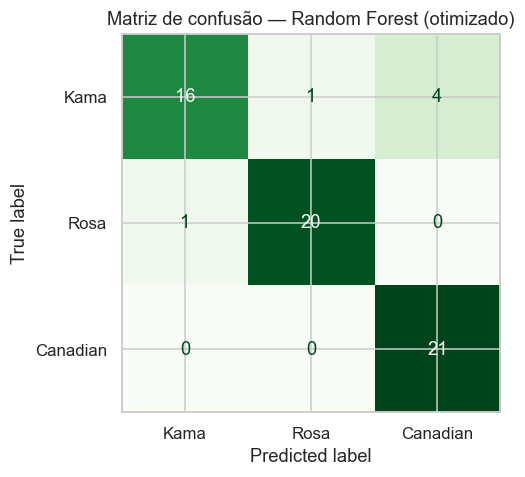

In [26]:
nome_melhor = resultados_otim["F1-score"].idxmax()
modelo_melhor = melhores_modelos[nome_melhor]
y_pred_melhor = modelo_melhor.predict(X_test)

print(f"MELHOR MODELO: {nome_melhor}")
print("=" * 55)
print(classification_report(y_test, y_pred_melhor, target_names=labels_nome, digits=4))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm = confusion_matrix(y_test, y_pred_melhor, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels_nome).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title(f"Matriz de confusão — {nome_melhor} (otimizado)")
plt.tight_layout(); plt.show()

### 5.5 Importância das características (Random Forest)

Independentemente de qual modelo vence, a Random Forest nos dá uma leitura valiosa de
**quais medições físicas mais pesam** na classificação — útil para a cooperativa saber
o que medir com mais cuidado.

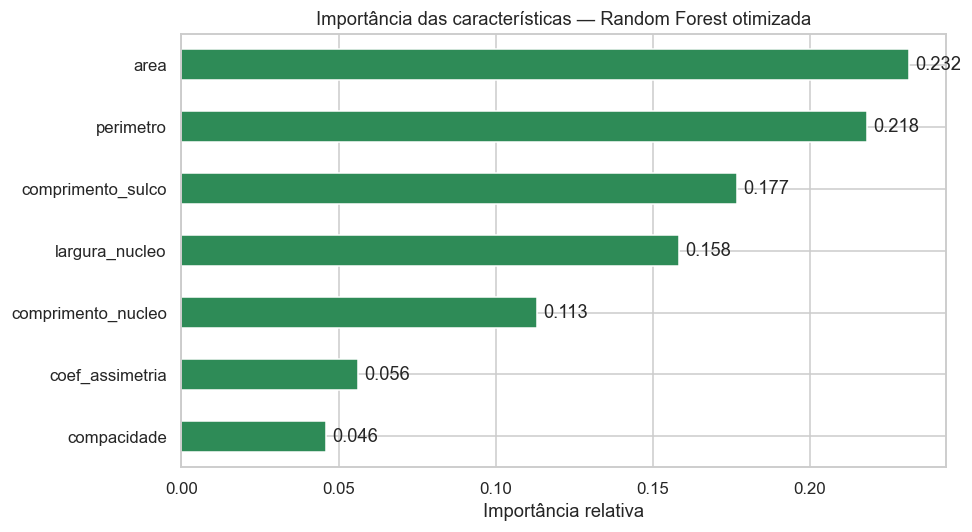

Ranking de importância:
area                 0.2316
perimetro            0.2182
comprimento_sulco    0.1768
largura_nucleo       0.1582
comprimento_nucleo   0.1132
coef_assimetria      0.0561
compacidade          0.0460


In [27]:
# Recupera o RandomForest otimizado e extrai importancias
rf_pipeline = melhores_modelos["Random Forest"]
rf_clf = rf_pipeline.named_steps["clf"]

importancias = pd.Series(rf_clf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
importancias.plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Importância das características — Random Forest otimizada")
ax.set_xlabel("Importância relativa")
for i, v in enumerate(importancias):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

print("Ranking de importância:")
print(importancias.sort_values(ascending=False).round(4).to_string())

## Fase 6 — Interpretação dos Resultados e Conclusões

### Síntese do desempenho *(números reais desta execução, `random_state=42`)*

| Modelo | Acurácia (base) | Acurácia (otimizado) | F1 base → otim. |
|--------|:---:|:---:|:---:|
| **Random Forest** | **0,921** | **0,905** | 0,919 → 0,903 |
| KNN | 0,873 | 0,889 | 0,871 → 0,888 |
| Regressão Logística | 0,857 | 0,889 | 0,854 → 0,888 |
| SVM | 0,873 | 0,857 | 0,871 → 0,854 |
| Naive Bayes | 0,825 | 0,825 | 0,825 → 0,825 |

- **Os cinco algoritmos ficaram numa faixa de acurácia de ~82% a ~92%.** O problema é
  bem-comportado (as variedades formam grupos separáveis), mas **não trivial**: com
  apenas 63 amostras de teste, cada erro vale ~1,6 ponto percentual, então as métricas
  oscilam.
- **A Random Forest foi o melhor modelo** tanto na configuração padrão (acurácia 0,921)
  quanto após otimização (0,905) — robusta e ainda interpretável. KNN e Regressão
  Logística vêm logo atrás (~0,89 otimizados); **Naive Bayes** ficou por último (0,825),
  consistente com sua premissa de independência entre features, que aqui é **violada**
  pela forte correlação entre as medidas de tamanho (Fase 2.10).

### A otimização melhorou? Sim e não — e isso é instrutivo

- A otimização **ajudou** KNN (+0,017 F1) e **Regressão Logística** (+0,034 F1), mas
  **piorou levemente** Random Forest (−0,017) e SVM (−0,017) **no conjunto de teste**.
- Por quê? Os scores de **validação cruzada no treino** foram altos (0,91–0,96), mas o
  teste ficou abaixo. Isso é o efeito clássico de **dataset pequeno**: a busca otimiza
  para o desempenho médio nos *folds* de treino, que nem sempre se traduz num teste de
  63 amostras. **Mais hiperparâmetro não garante mais acerto** — uma lição metodológica
  importante. O valor do Grid Search aqui é principalmente **robustez e validação**, não
  um salto de métrica.

### Onde os modelos erram (matrizes de confusão)

- No melhor modelo (Random Forest), o recall por classe foi: **Rosa 0,95**,
  **Canadian 1,00**, **Kama 0,76**. Ou seja, os erros concentram-se na variedade
  **Kama**, frequentemente classificada como **Canadian**.
- Isso confirma exatamente a hipótese da análise exploratória (Fase 2): a **Kama** tem
  **valores intermediários** de tamanho e fica geometricamente entre as outras duas,
  sendo a mais difícil de separar. A **Rosa** (grãos grandes) é a mais distinta e quase
  nunca é confundida.

### Características mais relevantes (Random Forest)

Ranking de importância: `area` (0,232) > `perimetro` (0,218) > `comprimento_sulco`
(0,177) > `largura_nucleo` (0,158) > `comprimento_nucleo` (0,113) > `coef_assimetria`
(0,056) > `compacidade` (0,046).

- As **medidas de tamanho dominam** a decisão. `compacidade` e `coef_assimetria`
  contribuem pouco isoladamente, mas adicionam o sinal de **forma** útil nos casos de
  fronteira (a Kama).
- Como as medidas de tamanho são altamente correlacionadas (Fase 2.10), há
  **redundância**: a cooperativa poderia obter boa classificação medindo um subconjunto
  delas, reduzindo o custo de coleta.

### Recomendações para a cooperativa (Deployment)

1. **Modelo recomendado: Random Forest otimizada** — melhor acurácia desta execução,
   robusta a *outliers*/ruído de medição do mundo real e que **não depende** de
   padronização cuidadosa de novos dados. KNN e Regressão Logística são alternativas
   leves e competitivas.
2. **Serializar o pipeline completo** (`scaler` + modelo) com `joblib` e versioná-lo,
   garantindo que novos grãos passem exatamente pelo mesmo pré-processamento.
3. **Monitorar a classe Kama**, alvo da maioria dos erros: amostras preditas com baixa
   confiança (`predict_proba`) deveriam ser encaminhadas para **conferência manual** —
   um fluxo *human-in-the-loop* que combina a velocidade da máquina com a segurança do
   especialista.
4. **Coleta de dados:** priorizar a precisão das medições de tamanho (área, perímetro,
   comprimentos), as mais informativas; e **coletar mais amostras** — 210 grãos é pouco,
   e mais dados tenderiam a estabilizar as métricas e estreitar a fronteira Kama/Canadian.

### Conclusão final

A metodologia **CRISP-DM** mostrou que é viável **automatizar a classificação de grãos
de trigo** com aprendizado de máquina: o melhor modelo (Random Forest) atingiu **~90–92%
de acurácia** em um conjunto pequeno (210 amostras), com erros concentrados na fronteira
naturalmente ambígua entre Kama e Canadian. Isso entrega à cooperativa um classificador
**rápido, consistente e reprodutível**, capaz de absorver a maior parte do trabalho
manual e liberar o especialista para os casos genuinamente difíceis — exatamente o
objetivo de negócio definido na Fase 1.